# KLE under CoT — TriviaQA / Llama-3.1-8B sonuç analizi

Bu notebook 4 sonuç dosyasını yükler, metrikleri yeniden hesaplar (raporlanan değerlerle
sanity-check) ve sonuç grafiklerini üretir.

| Cond | Tip | Açıklama |
|------|-----|----------|
| **C1** | black-box | Direct answer, no CoT (repo KLE baseline) |
| **C2** | black-box | Holistic CoT, full chain |
| **C3** | black-box | CoT + "Final Answer", answer-span extraction |
| **C4** | white-box | Step-wise hidden-state kernel-VNE (layer 16, cosine Gram) |

> **Skor yönü:** Tüm condition'larda yüksek skor = yüksek belirsizlik = hallucination olasılığı yüksek.
> AUROC, skorun (KLE / step-VNE) hallucination etiketini ne kadar iyi sıraladığını ölçer.

In [1]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3})

# >>> Dosyaların bulunduğu klasör. 4 json'u buraya koy.
DATA_DIR = "."

FILES = {
    "C1": ("c1_triviaqa_llama_bb.json", "bb"),
    "C2": ("c2_triviaqa_llama_bb.json", "bb"),
    "C3": ("c3_triviaiqa_llama_bb.json", "bb"),   # dosya adı "triviaiqa" yazılı
    "C4": ("c4_triviaqa_llama_wb.json", "wb"),
}

def load(cond):
    fn, kind = FILES[cond]
    with open(f"{DATA_DIR}/{fn}") as f:
        return json.load(f), kind

DATA = {c: load(c) for c in FILES}
print("Yüklendi:", {c: len(d["details"]) for c,(d,_) in DATA.items()})

Matplotlib is building the font cache; this may take a moment.


Yüklendi: {'C1': 1000, 'C2': 1000, 'C3': 1000, 'C4': 1000}


## 1. Skor + etiket çıkarımı

- **Black-box (C1–C3):** skor = `kle_full`, etiket = `judge_correct` False ise hallucination (1).
- **White-box (C4):** üç aggregation var — `agg.max`, `agg.mean`, `agg.attn_mean`; etiket = `is_halluc`.

In [2]:
def bb_scores(d):
    s = np.array([r["kle_full"] for r in d["details"]], float)
    y = np.array([0 if r["judge_correct"] else 1 for r in d["details"]], int)
    clusters = np.array([len(set(r["semantic_ids"])) for r in d["details"]], int)
    return s, y, clusters

def c4_scores(d, agg="attn_mean"):
    s = np.array([r["agg"][agg] for r in d["details"]], float)
    y = np.array([1 if r["is_halluc"] else 0 for r in d["details"]], int)
    return s, y

# Ana skor seti (C4 için attn_mean'i temsilci alıyoruz; varyantları ayrıca kıyaslayacağız)
SCORES = {}
for c in ["C1","C2","C3"]:
    d,_ = DATA[c]; s,y,cl = bb_scores(d); SCORES[c] = (s,y); 
d4,_ = DATA["C4"]; s4,y4 = c4_scores(d4,"attn_mean"); SCORES["C4"] = (s4,y4)
print("ok")

ok


## 2. Özet tablo (raporlanan vs. yeniden hesap)

Raporlanan AUROC ile yeniden hesaplanan AUROC eşleşmeli — eşleşmiyorsa skor/etiket
tanımında bir sorun var demektir.

In [3]:
rows = []
for c in ["C1","C2","C3"]:
    d,_ = DATA[c]; s,y,cl = bb_scores(d)
    rows.append(dict(cond=c, type="black-box",
                     auroc_recomp=roc_auc_score(y,s), auroc_reported=d["auroc"],
                     halluc_rate=y.mean(), mean_clusters=cl.mean(),
                     collapse_pct=(cl==1).mean()*100, N=len(y)))
d4,_ = DATA["C4"]
for agg in ["max","mean","attn_mean"]:
    s,y = c4_scores(d4,agg)
    rows.append(dict(cond=f"C4 ({agg})", type="white-box",
                     auroc_recomp=roc_auc_score(y,s), auroc_reported=d4["auroc"][agg],
                     halluc_rate=y.mean(), mean_clusters=np.nan,
                     collapse_pct=np.nan, N=len(y)))
summary = pd.DataFrame(rows).round(4)
summary

,cond,type,auroc_recomp,auroc_reported,halluc_rate,mean_clusters,collapse_pct,N
0,C1,black-box,0.8432,0.8432,0.244,5.294,11.1,1000
1,C2,black-box,0.7095,0.7095,0.190,6.690,1.0,1000
2,C3,black-box,0.8640,0.8640,0.239,4.440,16.2,1000
3,C4 (max),white-box,0.7846,0.7846,0.265,NaN,NaN,1000
4,C4 (mean),white-box,0.7729,0.7729,0.265,NaN,NaN,1000
5,C4 (attn_mean),white-box,0.7852,0.7852,0.265,NaN,NaN,1000


## 3. Grafik — AUROC by condition

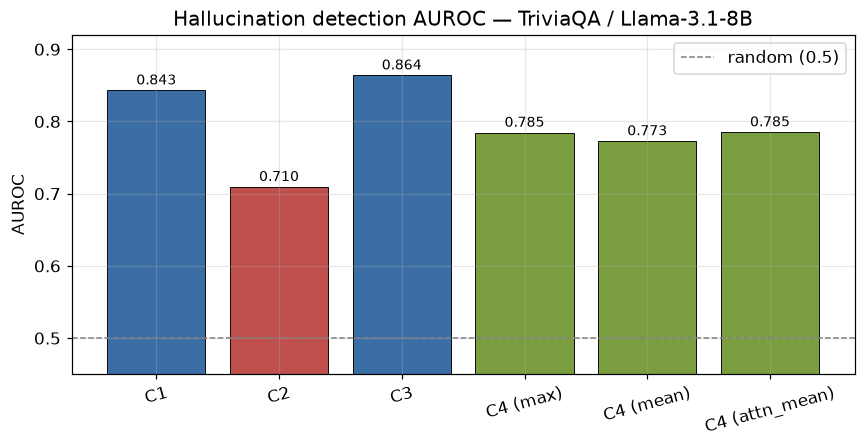

In [4]:
order = ["C1","C2","C3","C4 (max)","C4 (mean)","C4 (attn_mean)"]
sub = summary.set_index("cond").loc[order]
colors = ["#3b6ea5","#c0504d","#3b6ea5","#7a9e3f","#7a9e3f","#7a9e3f"]

fig, ax = plt.subplots(figsize=(8,4.2))
bars = ax.bar(order, sub["auroc_recomp"], color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(0.5, ls="--", color="gray", lw=1, label="random (0.5)")
for b,v in zip(bars, sub["auroc_recomp"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.45, 0.92); ax.set_ylabel("AUROC")
ax.set_title("Hallucination detection AUROC — TriviaQA / Llama-3.1-8B")
ax.legend(); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 4. Grafik — ROC eğrileri (4 condition üst üste)

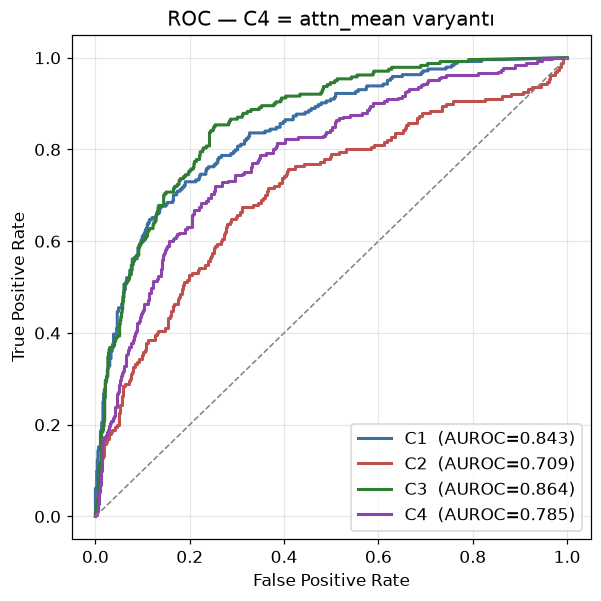

In [5]:
fig, ax = plt.subplots(figsize=(5.6,5.6))
palette = {"C1":"#3b6ea5","C2":"#c0504d","C3":"#2e7d32","C4":"#8e44ad"}
for c in ["C1","C2","C3","C4"]:
    s,y = SCORES[c]
    fpr,tpr,_ = roc_curve(y,s)
    a = roc_auc_score(y,s)
    ax.plot(fpr,tpr,label=f"{c}  (AUROC={a:.3f})",color=palette[c],lw=2)
ax.plot([0,1],[0,1],"--",color="gray",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — C4 = attn_mean varyantı"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 5. Grafik — Skor dağılımı: correct vs hallucination

Asıl ayırt ediciliği gösteren grafik. İki dağılım ne kadar ayrışıyorsa detection o kadar iyi.
C2'de örtüşmenin C1/C3'e göre fazla olmasını bekliyoruz (düşük AUROC'un görsel karşılığı).

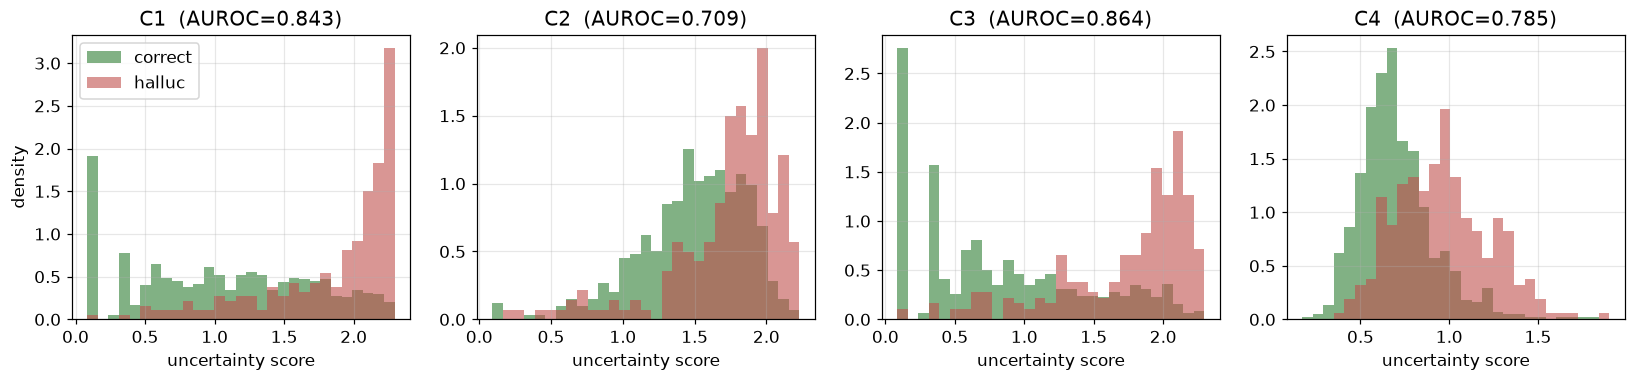

In [6]:
fig, axes = plt.subplots(1,4, figsize=(15,3.6), sharey=False)
for ax,c in zip(axes, ["C1","C2","C3","C4"]):
    s,y = SCORES[c]
    bins = np.linspace(s.min(), s.max(), 30)
    ax.hist(s[y==0], bins=bins, alpha=0.6, label="correct", color="#2e7d32", density=True)
    ax.hist(s[y==1], bins=bins, alpha=0.6, label="halluc",  color="#c0504d", density=True)
    ax.set_title(f"{c}  (AUROC={roc_auc_score(y,s):.3f})")
    ax.set_xlabel("uncertainty score")
axes[0].set_ylabel("density"); axes[0].legend()
plt.tight_layout(); plt.show()

## 6. Grafik — Cluster sayısı ve single-cluster collapse (black-box)

`semantic_ids`'ten türetilen unique cluster sayısı. Collapse (=1 cluster) sinyal kaybı demek.
C2'nin en yüksek ortalama cluster'a rağmen en düşük AUROC vermesi = **structural signal dilution**.

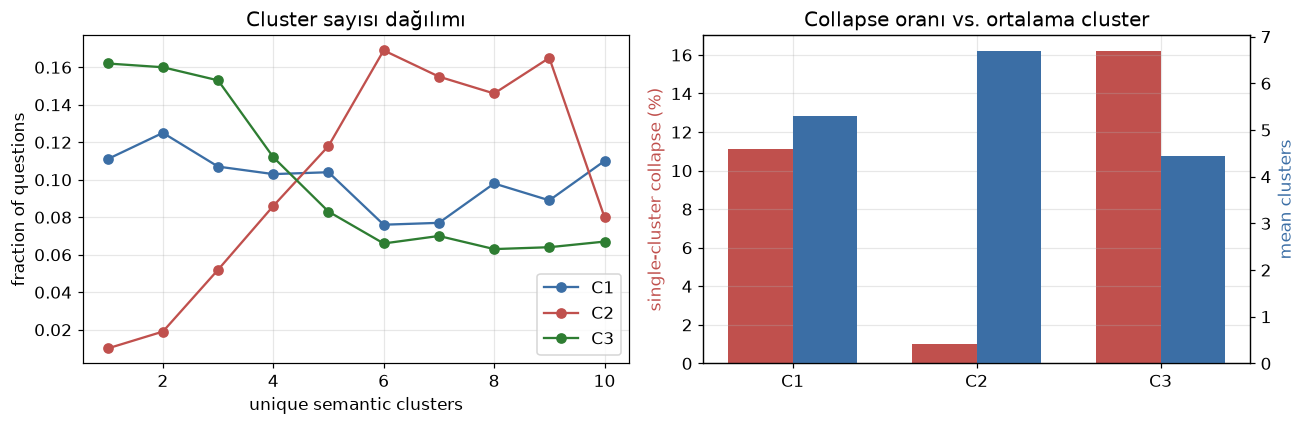

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
clu = {c: bb_scores(DATA[c][0])[2] for c in ["C1","C2","C3"]}

# (a) cluster sayısı dağılımı
for c,col in zip(["C1","C2","C3"], ["#3b6ea5","#c0504d","#2e7d32"]):
    vals = clu[c]
    h = np.bincount(vals, minlength=11)[1:11]
    axes[0].plot(range(1,11), h/ h.sum(), marker="o", label=c, color=col)
axes[0].set_xlabel("unique semantic clusters"); axes[0].set_ylabel("fraction of questions")
axes[0].set_title("Cluster sayısı dağılımı"); axes[0].legend()

# (b) collapse oranı + ortalama cluster
cond = ["C1","C2","C3"]
collapse = [ (clu[c]==1).mean()*100 for c in cond ]
meanc    = [ clu[c].mean() for c in cond ]
x = np.arange(len(cond)); w=0.35
ax2 = axes[1]; ax2b = ax2.twinx()
b1 = ax2.bar(x-w/2, collapse, w, color="#c0504d", label="collapse %")
b2 = ax2b.bar(x+w/2, meanc, w, color="#3b6ea5", label="mean clusters")
ax2.set_xticks(x); ax2.set_xticklabels(cond)
ax2.set_ylabel("single-cluster collapse (%)", color="#c0504d")
ax2b.set_ylabel("mean clusters", color="#3b6ea5")
ax2.set_title("Collapse oranı vs. ortalama cluster"); ax2b.grid(False)
plt.tight_layout(); plt.show()

## 7. Grafik — C4 aggregation varyantları + step davranışı

`max` / `mean` / `attn_mean` karşılaştırması ve adım sayısı dağılımı. TriviaQA single-hop
olduğu için `n_steps` neredeyse hep `max_steps`=3'e sabitleniyor — step-level'ın asıl testi
multi-hop datasetlerde.

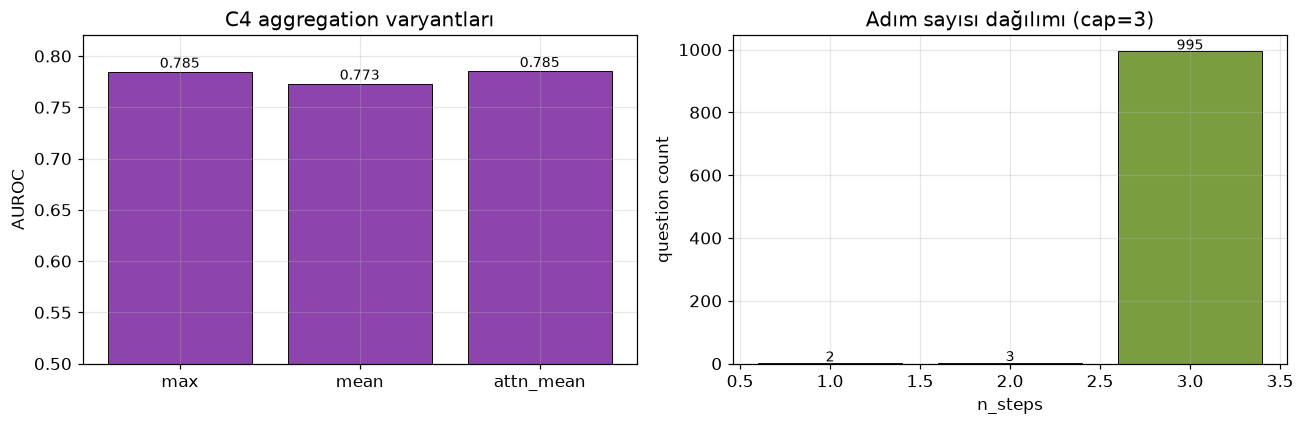

In [8]:
d4,_ = DATA["C4"]
fig, axes = plt.subplots(1,2, figsize=(12,4))

# (a) agg varyant AUROC
aggs = ["max","mean","attn_mean"]
aur = []
for a in aggs:
    s,y = c4_scores(d4,a); aur.append(roc_auc_score(y,s))
b = axes[0].bar(aggs, aur, color="#8e44ad", edgecolor="black", linewidth=0.6)
for bb,v in zip(b,aur): axes[0].text(bb.get_x()+bb.get_width()/2, v+0.004, f"{v:.3f}", ha="center", fontsize=9)
axes[0].set_ylim(0.5,0.82); axes[0].set_ylabel("AUROC"); axes[0].set_title("C4 aggregation varyantları")

# (b) n_steps dağılımı
ns = [r["n_steps"] for r in d4["details"]]
vals,counts = np.unique(ns, return_counts=True)
axes[1].bar(vals, counts, color="#7a9e3f", edgecolor="black", linewidth=0.6)
axes[1].set_xlabel("n_steps"); axes[1].set_ylabel("question count")
axes[1].set_title("Adım sayısı dağılımı (cap=3)")
for v,cnt in zip(vals,counts): axes[1].text(v, cnt+5, str(cnt), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Metrik açıklamaları (referans)

- **AUROC** — Skorun hallucination'ı doğru sıralama olasılığı. 1.0 = mükemmel, 0.5 = rastgele.
  Base-rate'e görece dayanıklıdır; condition'lar arası halluc oranı farklı olsa da karşılaştırılabilir.
- **Hallucination rate** — Etiketçinin (LLM-as-Judge, TriviaQA'da kısa cevap için F1<0.3) yanlış
  saydığı soruların oranı. Modelin *doğruluğunu* ölçer, *detection*'ı değil.
- **Unique semantic clusters** — `semantic_ids`'teki farklı NLI-entailment kümesi sayısı.
  KLE'nin belirsizlik sinyalinin ham kaynağı.
- **Single-cluster collapse** — Tüm sample'ların tek kümeye düştüğü sorular (=1 cluster).
  Belirsizlik sinyalinin kaybolduğu durum; non-strict entailment'te daha sık görülür.
- **C4 agg (max / mean / attn_mean)** — Adım-bazlı VNE skorlarının soru seviyesine indirgenmesi:
  en yüksek adım, ortalama, veya attention-ağırlıklı ortalama.

> **Not (RQ2):** Matched-granularity karşılaştırma için **black-box C4** dosyası gerekiyor;
> bu batch'te yalnızca white-box C4 var.

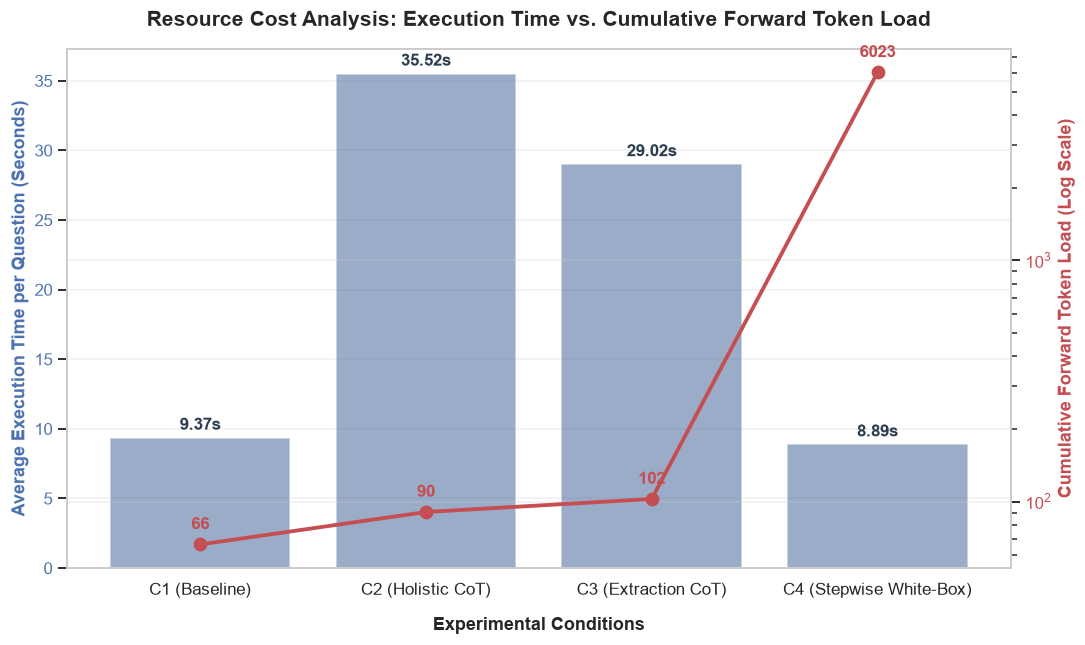

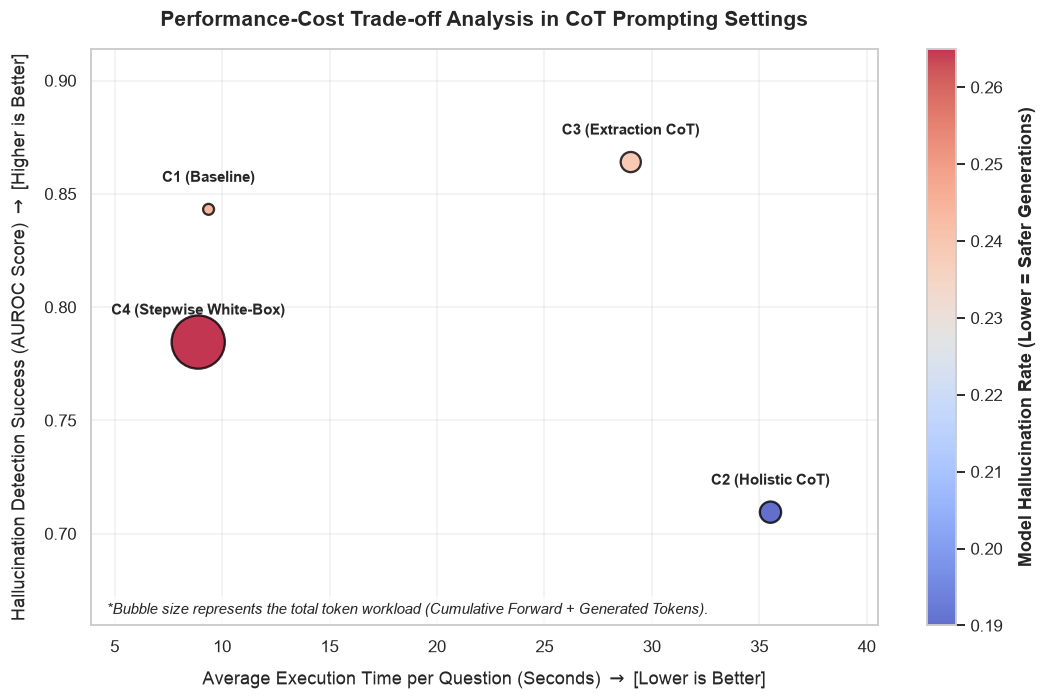

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-quality styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

# 1. Load and process pipeline results
files = {
    'C1 (Baseline)': 'c1_triviaqa_llama_bb.json',
    'C2 (Holistic CoT)': 'c2_triviaqa_llama_bb.json',
    'C3 (Extraction CoT)': 'c3_triviaiqa_llama_bb.json',
    'C4 (Stepwise White-Box)': 'c4_triviaqa_llama_wb.json'
}

data_list = []
for name, filename in files.items():
    with open(filename, 'r') as file:
        data = json.load(file)
        times, gen_tokens, fwd_tokens = [], [], []
        for d in data['details']:
            cost = d.get('cost', {})
            if cost:
                times.append(cost.get('t_seconds', 0))
                g_tok = cost.get('n_gen_tokens') if 'n_gen_tokens' in cost else cost.get('gen_tokens', 0)
                f_tok = cost.get('n_prompt_tokens') if 'n_prompt_tokens' in cost else cost.get('fwd_tokens', 0)
                gen_tokens.append(g_tok)
                fwd_tokens.append(f_tok)
        
        auroc = data.get('auroc')
        if isinstance(auroc, dict):
            auroc = auroc.get('max') # Using the primary aggregation (max) for C4
        
        data_list.append({
            'Condition': name,
            'Avg_Time': pd.Series(times).mean(),
            'Avg_Gen_Tokens': pd.Series(gen_tokens).mean(),
            'Avg_Fwd_Tokens': pd.Series(fwd_tokens).mean(),
            'AUROC': auroc,
            'Hallucination_Rate': data.get('hallucination_rate', 0)
        })

df_summary = pd.DataFrame(data_list)

# =====================================================================
# FIGURE 1: Dual-Axis Time vs Cumulative Forward Token Load
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

color = '#4c72b0'
ax1.set_xlabel('Experimental Conditions', fontweight='bold', labelpad=12)
ax1.set_ylabel('Average Execution Time per Question (Seconds)', color=color, fontweight='bold')

sns.barplot(x='Condition', y='Avg_Time', data=df_summary, color=color, alpha=0.6, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Resource Cost Analysis: Execution Time vs. Cumulative Forward Token Load', pad=15, fontweight='bold')

# Annotate bars with time values
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold', color='#2c3e50')

# Secondary axis for cumulative forward pass token load
ax2 = ax1.twinx()  
color = '#c44e52'
ax2.set_ylabel('Cumulative Forward Token Load (Log Scale)', color=color, fontweight='bold')
ax2.plot(df_summary['Condition'], df_summary['Avg_Fwd_Tokens'], color=color, marker='o', linewidth=2.5, markersize=8, label='Forward Tokens')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

# Annotate line with token counts
for i, val in enumerate(df_summary['Avg_Fwd_Tokens']):
    ax2.annotate(f"{int(val)}", (df_summary['Condition'][i], df_summary['Avg_Fwd_Tokens'][i]),
                textcoords="offset points", xytext=(0, 10), ha='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()


# =====================================================================
# FIGURE 2: Multi-dimensional Performance-Cost Trade-off (Bubble Chart)
# =====================================================================
fig2, ax3 = plt.subplots(figsize=(10, 6.5))

# Compute total computational weight (Forward + Generated Tokens) for bubble sizes
total_load = df_summary['Avg_Gen_Tokens'] + df_summary['Avg_Fwd_Tokens']

scatter = ax3.scatter(df_summary['Avg_Time'], df_summary['AUROC'], 
                     s=total_load * 0.15, # Scaled for visibility
                     c=df_summary['Hallucination_Rate'], 
                     cmap='coolwarm', alpha=0.8, edgecolors='black', linewidth=1.5)

ax3.set_title('Performance-Cost Trade-off Analysis in CoT Prompting Settings', pad=15, fontweight='bold')
ax3.set_xlabel('Average Execution Time per Question (Seconds) $\\rightarrow$ [Lower is Better]', labelpad=10)
ax3.set_ylabel('Hallucination Detection Success (AUROC Score) $\\rightarrow$ [Higher is Better]', labelpad=10)

# Label each point safely
for i, txt in enumerate(df_summary['Condition']):
    ax3.annotate(txt, (df_summary['Avg_Time'][i], df_summary['AUROC'][i]), textcoords="offset points", 
                xytext=(0, 18), ha='center', weight='bold', fontsize=10)

# Colorbar for the model's base generation hallucination rates
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Model Hallucination Rate (Lower = Safer Generations)', labelpad=10, fontweight='bold')

# Optimize view boundaries
ax3.set_xlim(df_summary['Avg_Time'].min() - 5, df_summary['Avg_Time'].max() + 5)
ax3.set_ylim(df_summary['AUROC'].min() - 0.05, df_summary['AUROC'].max() + 0.05)

# Footnote to explain bubble scaling
ax3.text(0.02, 0.02, '*Bubble size represents the total token workload (Cumulative Forward + Generated Tokens).', 
         transform=ax3.transAxes, fontsize=9.5, style='italic', bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()
plt.show()